# Evaluation and model comparison
Review per-finding and macro metrics, validation ROC/precision–recall curves, confusion matrices and prediction examples. AUROC is not percentage accuracy. The saved decision thresholds were selected on internal validation F1, and the displayed operating characteristics may be unsuitable for clinical use.


In [1]:
from pathlib import Path
import sys, json
candidates = [Path.cwd(), Path.cwd().parent]
ROOT = next((p for p in candidates if (p / "config.yaml").exists() and (p / "src").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Open this notebook from KneeAssist-AI or its notebooks folder.")
sys.path.insert(0, str(ROOT))
from src.utils import config
cfg = config(ROOT / "config.yaml")
print("Project:", ROOT)
print("Python:", sys.executable)


Project: C:\Users\HP\Desktop\KneeAssist-AI
Python: C:\Users\HP\Desktop\KneeAssist-AI\.venv\Scripts\python.exe


In [2]:
import pandas as pd
from IPython.display import display, Image, Markdown
report = json.loads((ROOT / cfg["evaluation"]["directory"] / "final/metrics.json").read_text())
comparison = json.loads((ROOT / cfg["evaluation"]["directory"] / "model_comparison.json").read_text())
print("Selected model:", report["architecture"])
print("Validation studies:", report["exams"])
metrics = report["metrics"]
columns = ["auroc", "f1", "sensitivity", "specificity", "precision", "accuracy", "average_precision"]
display(pd.DataFrame({k: {c: v[c] for c in columns} for k, v in metrics.items()}).T)


Selected model: efficientnet_b0
Validation studies: 120


,auroc,f1,sensitivity,specificity,precision,accuracy,average_precision
abnormal,0.900632,0.927083,0.936842,0.680000,0.917526,0.883333,0.967954
acl,0.825196,0.745763,0.814815,0.696970,0.687500,0.750000,0.799131
meniscus,0.754242,0.630631,0.673077,0.647059,0.593220,0.658333,0.706306
macro,0.826690,0.767826,0.808245,0.674676,0.732749,0.763889,0.824464


In [3]:
from src.evaluation.metrics import calculate
predictions = pd.read_csv(ROOT / cfg["evaluation"]["directory"] / "final/predictions.csv", dtype={"study_id": str})
keys = [t["key"] for t in cfg["targets"]]
y = predictions[[k + "_label" for k in keys]].to_numpy()
p = predictions[[k + "_probability" for k in keys]].to_numpy()
thresholds = {k: metrics[k]["threshold"] for k in keys}
recomputed = calculate(y, p, cfg["targets"], thresholds)
assert abs(recomputed["macro"]["auroc"] - metrics["macro"]["auroc"]) < 1e-10
print("Saved predictions reproduce the reported macro AUROC.")
display(pd.DataFrame([{"Finding": t["display"], "Threshold": metrics[t["key"]]["threshold"], "Confusion matrix [[TN,FP],[FN,TP]]": metrics[t["key"]]["confusion_matrix"]} for t in cfg["targets"]]))


Saved predictions reproduce the reported macro AUROC.


,Finding,Threshold,"Confusion matrix [[TN,FP],[FN,TP]]"
0,General Abnormality,0.694368,"[[17, 8], [6, 89]]"
1,ACL Tear,0.246083,"[[46, 20], [10, 44]]"
2,Meniscal Tear,0.480775,"[[44, 24], [17, 35]]"


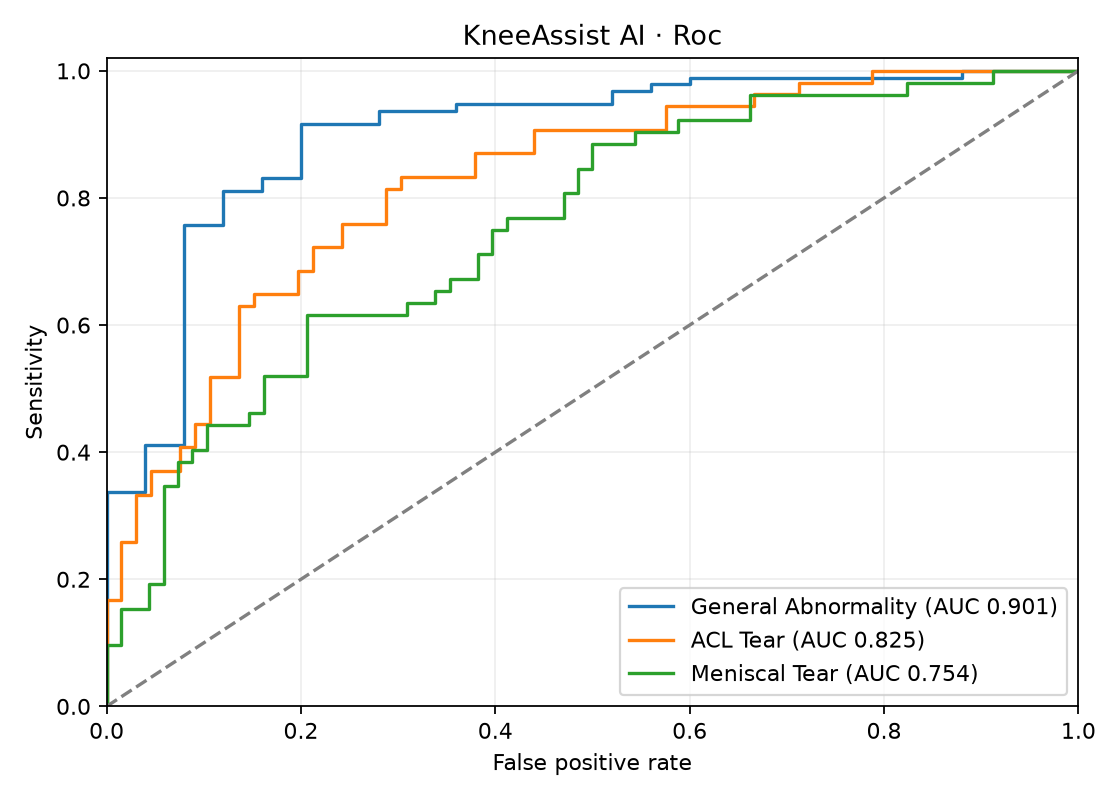

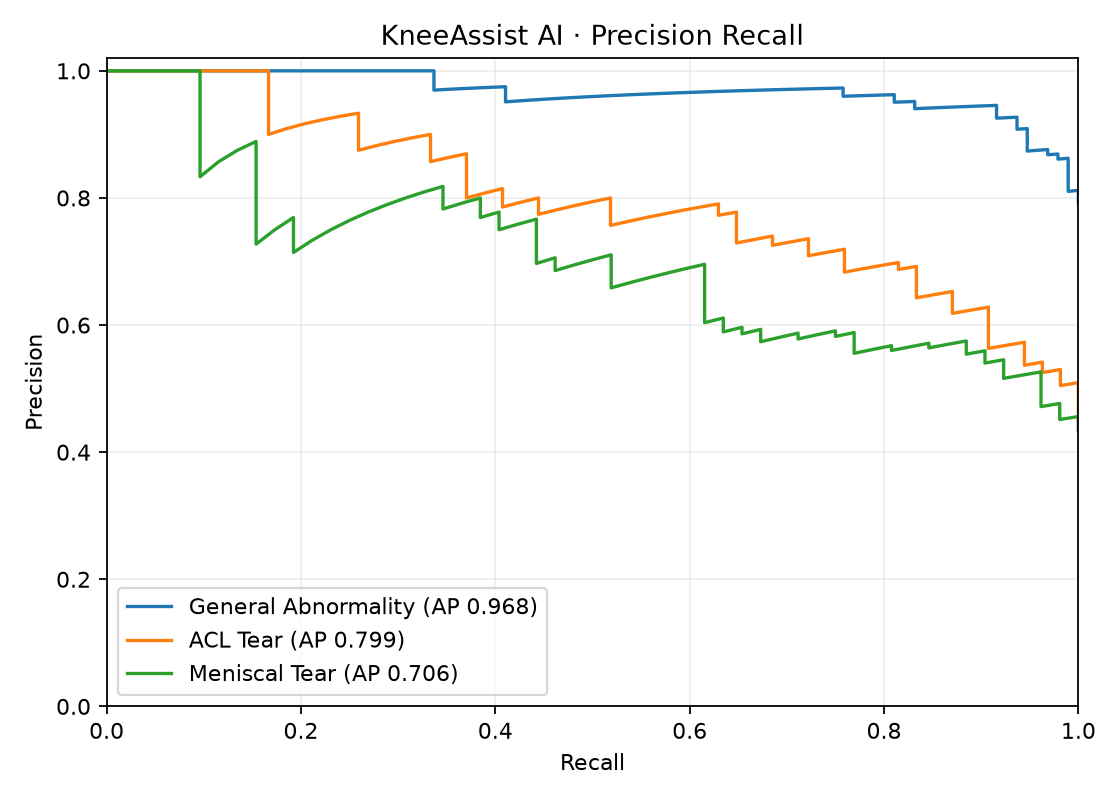

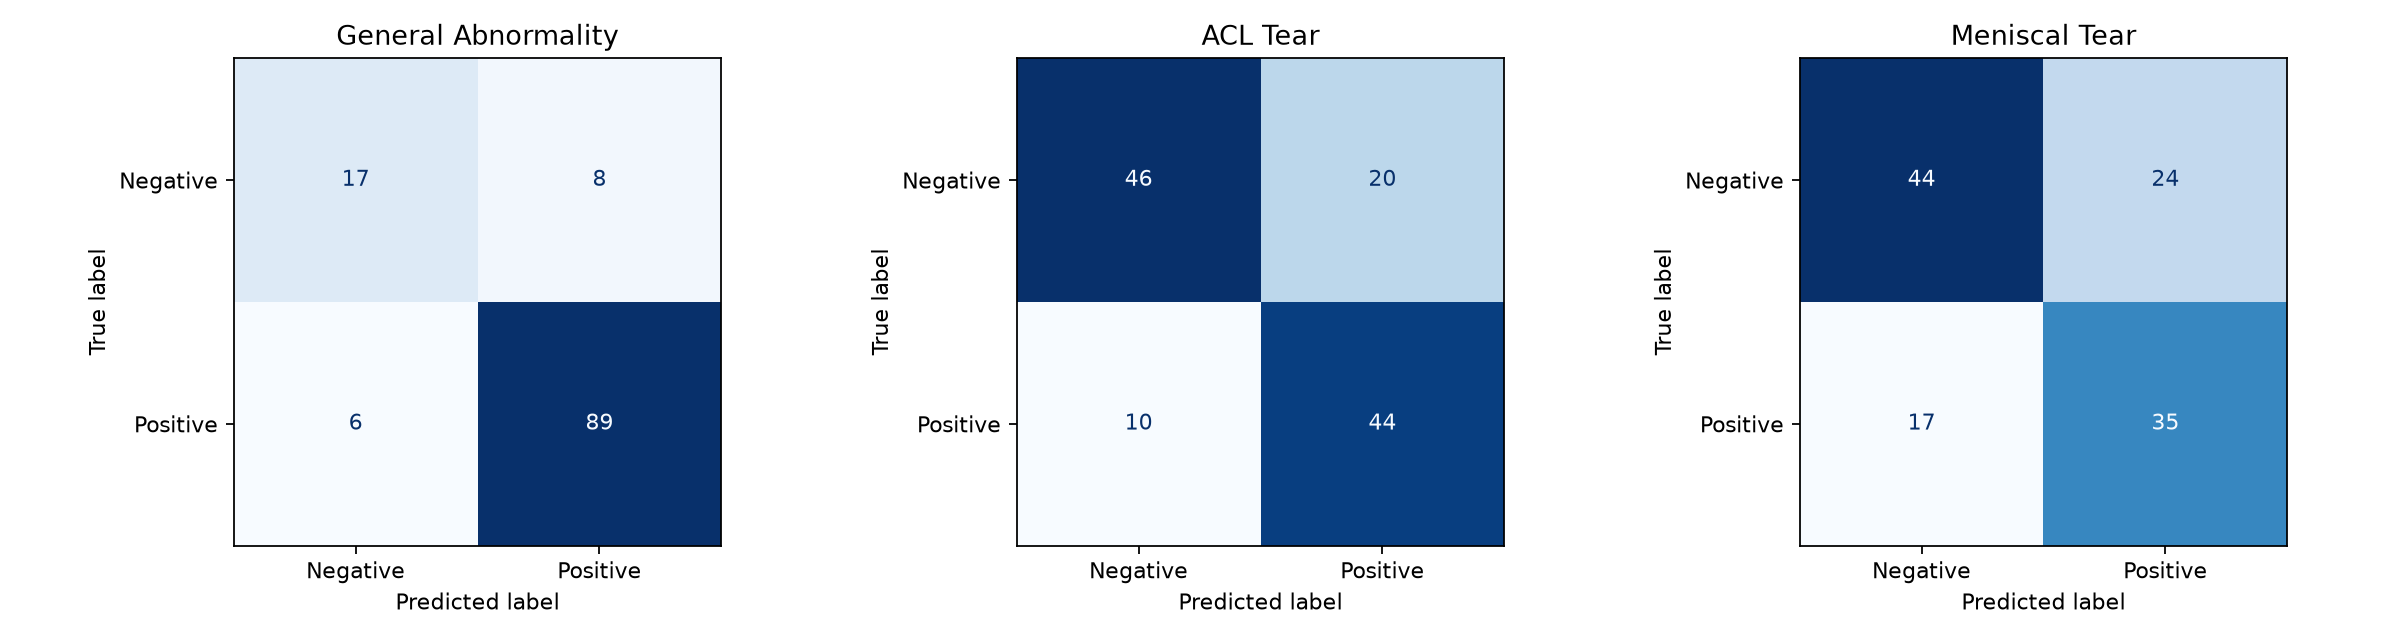

In [4]:
for filename in ["roc_curves.png", "precision_recall_curves.png", "confusion_matrices.png"]:
    display(Image(filename=str(ROOT / cfg["evaluation"]["directory"] / "final" / filename)))


# KneeAssist AI â€” evaluation

Selected architecture: **efficientnet_b0**. Selected checkpoint stage: **frozen_warmup**. Fine-tuning was tested, but the frozen warm-up checkpoint won selection.

Selection used internal validation macro AUROC. Threshold procedure: reserved_calibration_youden. Official validation was not used for either decision.

| Model | Internal validation macro AUROC | Selected epoch |
|---|---:|---:|
| resnet18 | 0.848 | 5 |
| efficientnet_b0 | 0.853 | 0 |
| efficientnet_b0 | 0.848 | 3 |

## Official validation (120 exams)

| Finding | AUROC | F1 | Sensitivity | Specificity | Precision | Accuracy |
|---|---:|---:|---:|---:|---:|---:|
| General Abnormality | 0.901 | 0.927 | 0.937 | 0.680 | 0.918 | 0.883 |
| ACL Tear | 0.825 | 0.746 | 0.815 | 0.697 | 0.688 | 0.750 |
| Meniscal Tear | 0.754 | 0.631 | 0.673 | 0.647 | 0.593 | 0.658 |
| Macro average | 0.827 | 0.768 | 0.808 | 0.675 | 0.733 | 0.764 |

AUROC is a ranking metric, not percentage accuracy. The official validation cohort was used in the earlier prototype, so these are development-validation results, not a new external test. Patient independence is not verified without a patient mapping. Probabilities and score-separation indicators are not clinically calibrated. Attention maps are not confirmed lesions.

The current checkpoints support abnormality, ACL tear and meniscal tear only. RSNA and X-ray data were not used for these checkpoints. Research and clinical decision-support prototype; clinician review required.

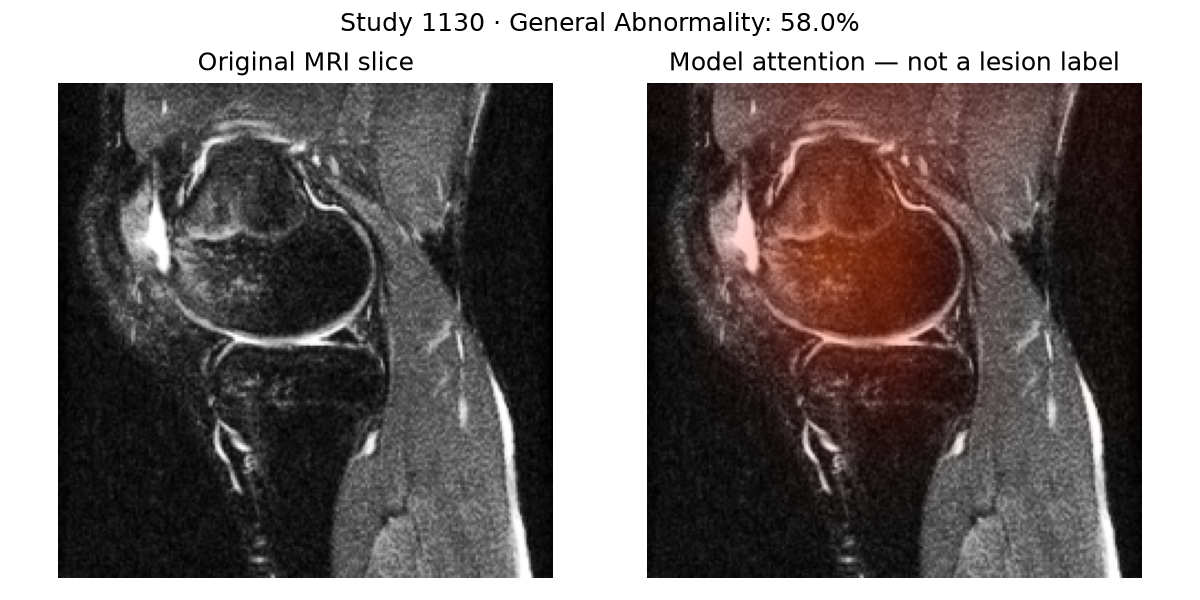

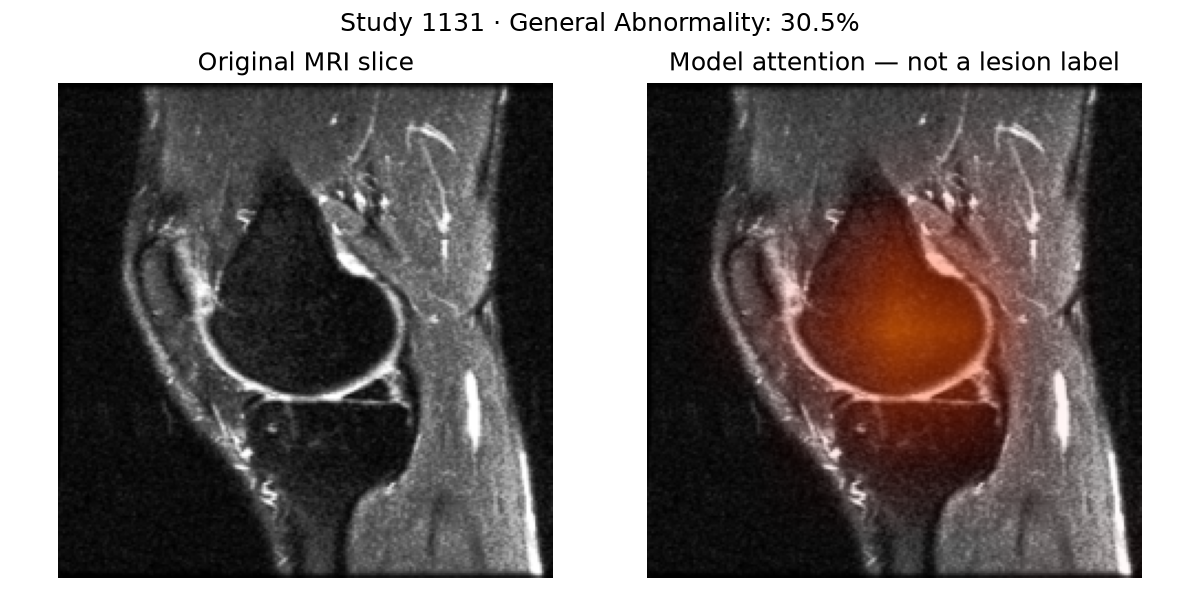

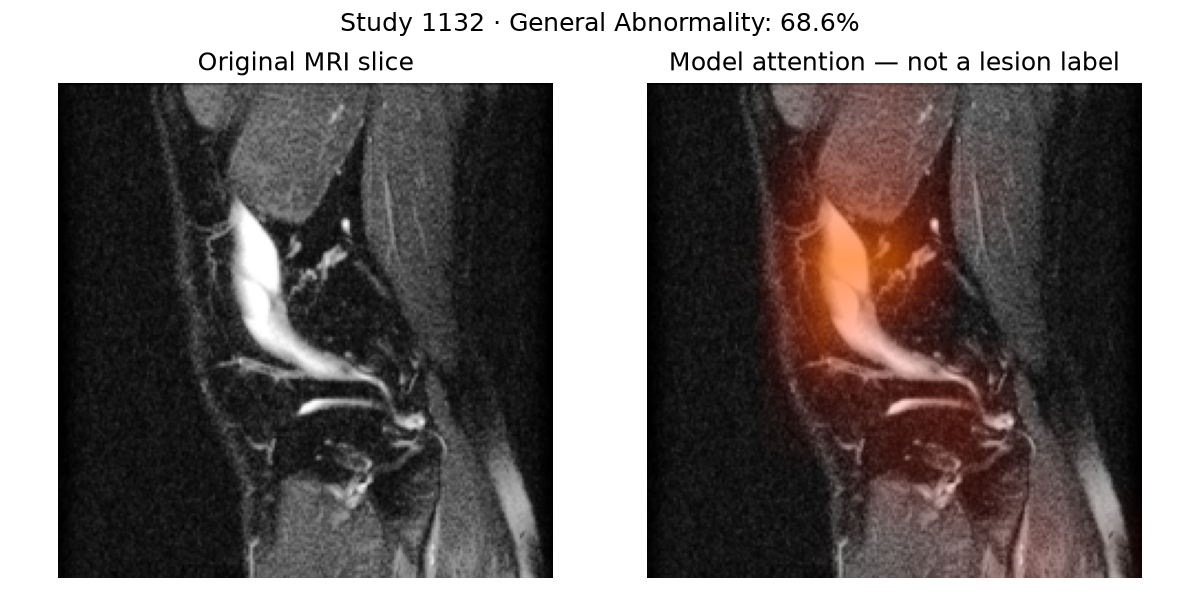

In [5]:
display(Markdown((ROOT / cfg["evaluation"]["directory"] / "REPORT.md").read_text(encoding="utf-8")))
for path in sorted((ROOT / cfg["evaluation"]["directory"] / "final").glob("example_*.png")):
    display(Image(filename=str(path)))


## Limitations to retain with every result
The 120-study cohort is small and was used in the earlier prototype. Patient-level linkage, external hospital evaluation, prospective validation and probability calibration are missing. Examine specificity and missed-positive counts, not AUROC alone. Heatmaps are decision-support visualizations, not lesion labels.
